# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 ULTRA-ATTENTIVE PIPELINE running on: cuda
Loading Data...

--- PHASE A: ENGINEERING RICH FEATURES ---
Fitting NCA...
Generating Isolation Embeddings...
Training Autoencoder (20 Epochs)...

--- PHASE B: MANIFOLD MIXUP ---
Synthesizing Class r2l: 796 -> 2000
Synthesizing Class u2r: 42 -> 2000
Balanced Data: torch.Size([103940, 58])

--- PHASE C: ATTENTIVE DISTILLATION ---
Training Teacher...
Distilling to Attentive Student...

--- PHASE D: EXTERNAL VALIDATION (NSL-KDD Test+) ---
Transforming Test Data...

   🔥 FINAL SCORE: 79.99% (MCC: 0.7087) 🔥
              precision    recall  f1-score   support

         dos       0.96      0.84      0.89      7458
      normal       0.74      0.97      0.83      9711
       probe       0.76      0.75      0.75      2421
         r2l       0.90      0.20      0.33      2887
         u2r       0.11      0.45      0.17        67

    accuracy                           0.80     22544
   macro avg       0.69      0.64      0.60     22544
weighted avg  

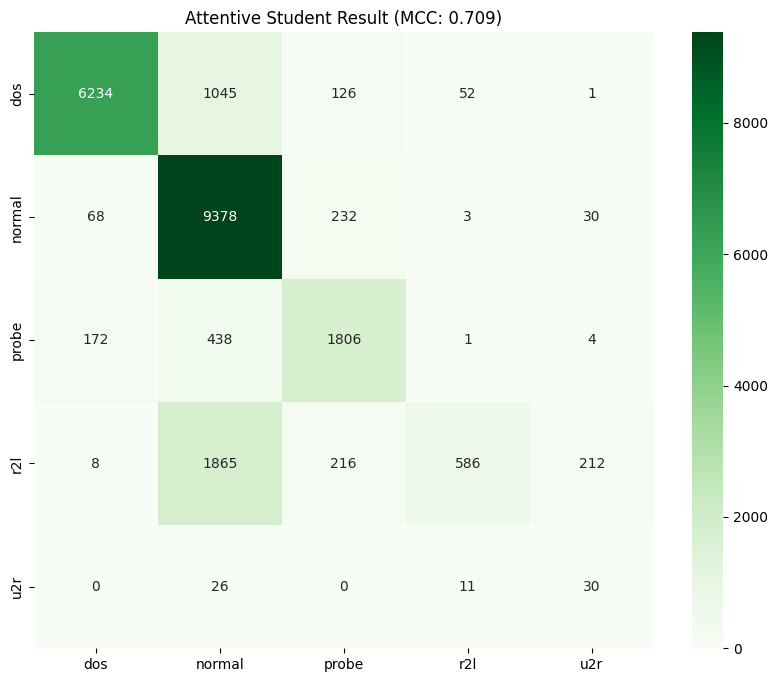

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 ULTRA-ATTENTIVE PIPELINE running on: {device}")

# ==========================================
# 1. DATA LOADING & PREP
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

def load_data(path):
    print("Loading Data...")
    df = pd.read_csv(path)
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])
            
    X = df.drop(['label', 'category'], axis=1).select_dtypes(include=[np.number])
    y = df['category']
    return X, y

X, y = load_data('Data/network_connections.csv')

le = LabelEncoder()
y_vec = le.fit_transform(y)
num_classes = len(le.classes_)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_vec, test_size=0.2, stratify=y_vec, random_state=42)

# ==========================================
# 2. RICH FEATURE ENGINEERING
# ==========================================
print("\n--- PHASE A: ENGINEERING RICH FEATURES ---")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_sc = scaler.transform(X_test_raw).astype(np.float32)

print("Fitting NCA...")
nca = NeighborhoodComponentsAnalysis(n_components=15, random_state=42)
idx_sample = np.random.choice(len(X_train_sc), size=min(10000, len(X_train_sc)), replace=False)
nca.fit(X_train_sc[idx_sample], y_train[idx_sample])
X_train_nca = nca.transform(X_train_sc).astype(np.float32)
X_test_nca = nca.transform(X_test_sc).astype(np.float32)

print("Generating Isolation Embeddings...")
iso_models = {}
iso_feats_train = []
iso_feats_test = []
for cls_idx in np.unique(y_train):
    X_cls = X_train_sc[y_train == cls_idx]
    if len(X_cls) < 50: continue
    iso = IsolationForest(n_estimators=50, contamination=0.01, n_jobs=-1, random_state=42)
    iso.fit(X_cls)
    iso_models[cls_idx] = iso
    iso_feats_train.append(iso.decision_function(X_train_sc).reshape(-1, 1).astype(np.float32))
    iso_feats_test.append(iso.decision_function(X_test_sc).reshape(-1, 1).astype(np.float32))

X_train_iso = np.hstack(iso_feats_train)
X_test_iso = np.hstack(iso_feats_test)

print("Training Autoencoder (20 Epochs)...")
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x): return self.net(x)

ae = Autoencoder(X_train_sc.shape[1]).to(device)
ae_opt = optim.Adam(ae.parameters(), lr=0.005)
ae_loader = DataLoader(TensorDataset(torch.tensor(X_train_sc).to(device)), batch_size=512, shuffle=True)

for epoch in range(20):
    for batch in ae_loader:
        x = batch[0]
        loss = F.mse_loss(ae(x), x)
        ae_opt.zero_grad(); loss.backward(); ae_opt.step()

def get_recon_error(data):
    with torch.no_grad():
        t = torch.tensor(data).to(device)
        return torch.mean((t - ae(t))**2, dim=1).cpu().numpy().reshape(-1, 1).astype(np.float32)

X_train_ae = get_recon_error(X_train_sc)
X_test_ae = get_recon_error(X_test_sc)

# COMBINE ALL FEATURES
X_train_final = np.hstack([X_train_sc, X_train_nca, X_train_iso, X_train_ae])
X_test_final = np.hstack([X_test_sc, X_test_nca, X_test_iso, X_test_ae])

# ==========================================
# 3. MANIFOLD MIXUP (Synthesize Rare Attacks)
# ==========================================
print("\n--- PHASE B: MANIFOLD MIXUP ---")

def mixup_data(x, y, alpha=0.2):
    if alpha > 0: lam = np.random.beta(alpha, alpha)
    else: lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam # Simplification: use same label for intra-class mixup

X_t = torch.tensor(X_train_final).to(device)
y_t = torch.tensor(y_train).to(device)

X_bal_list, y_bal_list = [X_t], [y_t]
target_count = 2000

for cls_idx in np.unique(y_train):
    mask = (y_train == cls_idx)
    count = mask.sum()
    if count < target_count:
        print(f"Synthesizing Class {le.classes_[cls_idx]}: {count} -> {target_count}")
        x_rare = X_t[torch.tensor(mask).to(device)]
        y_rare = y_t[torch.tensor(mask).to(device)]
        
        needed = target_count - count
        generated = []
        for _ in range(int(np.ceil(needed / count))):
            # Intra-class mixup (safe)
            mixed_x, _, _, _ = mixup_data(x_rare, y_rare, alpha=0.3)
            generated.append(mixed_x)
            
        X_bal_list.append(torch.cat(generated)[:needed])
        y_bal_list.append(torch.full((needed,), cls_idx).to(device))

X_train_bal = torch.cat(X_bal_list)
y_train_bal = torch.cat(y_bal_list)
print(f"Balanced Data: {X_train_bal.shape}")

# ==========================================
# 4. TEACHER & ATTENTIVE STUDENT
# ==========================================
print("\n--- PHASE C: ATTENTIVE DISTILLATION ---")

# Mish Activation
class Mish(nn.Module):
    def forward(self, x): return x * torch.tanh(F.softplus(x))

# SE Block (Attention)
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            Mish(),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x)

# Teacher (Robust MLP)
class VectorTeacher(nn.Module):
    def __init__(self, input_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), Mish(), nn.Dropout(0.2),
            nn.Linear(256, 256),       nn.BatchNorm1d(256), Mish(), nn.Dropout(0.2),
            nn.Linear(256, 128)
        )
        self.head = nn.Linear(128, out_dim)
    def forward(self, x):
        emb = F.normalize(self.net(x), p=2, dim=1)
        return emb, self.head(emb)

# Attentive Student
class AttentiveStudent(nn.Module):
    def __init__(self, input_dim, out_dim, embed_dim=128):
        super().__init__()
        # Expand & Attend
        self.layer1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.act1 = Mish()
        self.att1 = SEBlock(256, reduction=8) # Attention!
        
        # Compress
        self.layer2 = nn.Linear(256, embed_dim)
        
        # Head
        self.head = nn.Linear(embed_dim, out_dim)

    def forward(self, x):
        x = self.act1(self.bn1(self.layer1(x)))
        x = self.att1(x) # Weight important features (e.g. Anomaly Score)
        
        embed = F.normalize(self.layer2(x), p=2, dim=1)
        logits = self.head(embed)
        return embed, logits

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.5):
        super().__init__()
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        return ((1-pt)**self.gamma * ce).mean()

# Train Setup
train_dl = DataLoader(TensorDataset(X_train_bal, y_train_bal), batch_size=256, shuffle=True)

# 1. Train Teacher
teacher = VectorTeacher(X_train_final.shape[1], num_classes).to(device)
opt_t = optim.AdamW(teacher.parameters(), lr=0.001)
sched_t = optim.lr_scheduler.CosineAnnealingLR(opt_t, T_max=25)
crit = FocalLoss()

print("Training Teacher...")
for epoch in range(25):
    teacher.train()
    for x, y in train_dl:
        opt_t.zero_grad()
        _, logits = teacher(x)
        loss = crit(logits, y)
        loss.backward(); opt_t.step()
    sched_t.step()

# 2. Train Attentive Student
student = AttentiveStudent(X_train_final.shape[1], num_classes).to(device)
opt_s = optim.AdamW(student.parameters(), lr=0.002)

print("Distilling to Attentive Student...")
teacher.eval()
for epoch in range(40): # More epochs for attention to settle
    student.train()
    for x, y in train_dl:
        opt_s.zero_grad()
        s_emb, s_logits = student(x)
        with torch.no_grad(): t_emb, t_logits = teacher(x)
        
        # Cosine Loss for Embedding (Better for angles)
        l_feat = (1 - F.cosine_similarity(s_emb, t_emb)).mean()
        l_kd = nn.KLDivLoss(reduction='batchmean')(F.log_softmax(s_logits/4.0, 1), F.softmax(t_logits/4.0, 1)) * 16
        l_cls = crit(s_logits, y)
        
        loss = 0.6*l_feat + 0.3*l_kd + 0.1*l_cls
        loss.backward(); opt_s.step()

# ==========================================
# 5. VALIDATION (NSL-KDD Test+)
# ==========================================
print("\n--- PHASE D: EXTERNAL VALIDATION (NSL-KDD Test+) ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    if 'difficulty_level' in df_nsl.columns: df_nsl.drop('difficulty_level', axis=1, inplace=True)
    
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    if 'src_bytes' in df_nsl.columns:
        df_nsl['byte_ratio'] = (np.log1p(df_nsl['src_bytes'])) / (np.log1p(df_nsl['dst_bytes']) + 1)
        df_nsl['srv_diff'] = df_nsl['srv_count'] - df_nsl['count']
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df_nsl.columns: df_nsl[c] = np.log1p(df_nsl[c])
            
    # Align Columns
    train_cols = list(X.columns)
    df_nsl_aligned = pd.DataFrame(0, index=np.arange(len(df_nsl)), columns=train_cols)
    for c in train_cols:
        if c in df_nsl.columns: df_nsl_aligned[c] = df_nsl[c]
            
    y_nsl_vec = df_nsl['category'].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values
    
    print("Transforming Test Data...")
    X_nsl_sc = scaler.transform(df_nsl_aligned).astype(np.float32)
    X_nsl_nca = nca.transform(X_nsl_sc).astype(np.float32)
    
    iso_feats_nsl = []
    for cls_idx in np.sort(list(iso_models.keys())):
        iso_feats_nsl.append(iso_models[cls_idx].decision_function(X_nsl_sc).reshape(-1, 1).astype(np.float32))
    X_nsl_iso = np.hstack(iso_feats_nsl)
    
    X_nsl_ae = get_recon_error(X_nsl_sc)
    X_nsl_final = np.hstack([X_nsl_sc, X_nsl_nca, X_nsl_iso, X_nsl_ae])
    
    # Inference with Thresholds
    student.eval()
    preds = []
    idx_u2r = list(le.classes_).index('u2r') if 'u2r' in le.classes_ else -1
    idx_r2l = list(le.classes_).index('r2l') if 'r2l' in le.classes_ else -1
    
    with torch.no_grad():
        loader = DataLoader(TensorDataset(torch.tensor(X_nsl_final).to(device)), batch_size=1024)
        for x in loader:
            _, logits = student(x[0])
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            batch_p = []
            for p in probs:
                if idx_u2r != -1 and p[idx_u2r] > 0.10: batch_p.append(idx_u2r)
                elif idx_r2l != -1 and p[idx_r2l] > 0.15: batch_p.append(idx_r2l)
                else: batch_p.append(np.argmax(p))
            preds.append(batch_p)
            
    final_preds = np.concatenate(preds)
    
    mask = y_nsl_vec != -1
    acc = accuracy_score(y_nsl_vec[mask], final_preds[mask])
    mcc = matthews_corrcoef(y_nsl_vec[mask], final_preds[mask])
    
    print("\n" + "="*40)
    print(f"   🔥 FINAL SCORE: {acc:.2%} (MCC: {mcc:.4f}) 🔥")
    print("="*40)
    print(classification_report(y_nsl_vec[mask], final_preds[mask], target_names=le.classes_))
    
    labels = sorted(list(set(y_nsl_vec[mask]) | set(final_preds[mask])))
    label_names = [le.classes_[i] for i in labels]
    plt.figure(figsize=(10,8))
    sns.heatmap(confusion_matrix(y_nsl_vec[mask], final_preds[mask], labels=labels), 
                annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Attentive Student Result (MCC: {mcc:.3f})")
    plt.show()

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()